# Perceptron

## Learning objective

This notebook introduces the **perceptron**, one of the earliest models for
*binary linear classification*. By the end you should be able to:

- describe how a perceptron separates two classes with a straight decision
  boundary,
- state the perceptron update rule and the idea behind it,
- implement a small perceptron classifier from scratch with `fit` and
  `predict`, and
- explain when the algorithm converges and why it struggles on data that is
  not linearly separable.

## The mathematical idea

A perceptron is a linear classifier. For an input vector
$\mathbf{x} \in \mathbb{R}^d$ it computes a weighted sum plus a bias and
looks at the sign of the result:

$$
\hat{y} = \operatorname{sign}(\mathbf{w}^\top \mathbf{x} + b).
$$

The set of points where $\mathbf{w}^\top \mathbf{x} + b = 0$ is the
**decision boundary**, a line in 2D (a hyperplane in general). Points on one
side are labelled $+1$ and points on the other side $-1$.

Training proceeds one example at a time. For a labelled point
$(\mathbf{x}_i, y_i)$ with $y_i \in \{-1, +1\}$, the perceptron makes a
prediction and, **only when it is wrong**, nudges the weights toward the
correct answer:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta\, y_i\, \mathbf{x}_i,
\qquad
b \leftarrow b + \eta\, y_i,
$$

where $\eta > 0$ is the learning rate. The update moves the boundary so that
the misclassified point is pushed toward its correct side.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Deterministic results across runs.
rng = np.random.default_rng(42)

## A small synthetic dataset

We build a tiny, clearly **linearly separable** 2D dataset: two Gaussian
blobs with different centers. Because the blobs do not overlap, a straight
line can perfectly separate them, which is exactly the situation in which the
perceptron is guaranteed to succeed.

In [2]:
n_per_class = 30

# Class +1 centered at (2, 2); class -1 centered at (-2, -2).
X_pos = rng.normal(loc=[2.0, 2.0], scale=0.75, size=(n_per_class, 2))
X_neg = rng.normal(loc=[-2.0, -2.0], scale=0.75, size=(n_per_class, 2))

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])

# Shuffle so the two classes are interleaved during training.
order = rng.permutation(len(y))
X, y = X[order], y[order]

print('Feature matrix shape:', X.shape)
print('Class counts:', {int(c): int((y == c).sum()) for c in (-1, 1)})

Feature matrix shape: (60, 2)
Class counts: {-1: 30, 1: 30}


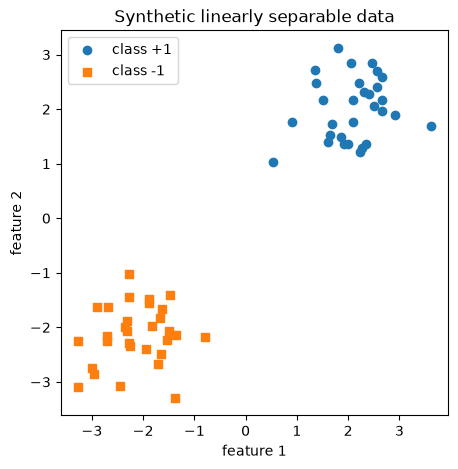

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='o', label='class +1')
ax.scatter(X[y == -1, 0], X[y == -1, 1], marker='s', label='class -1')
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Synthetic linearly separable data')
ax.legend()
plt.show()

## A perceptron from scratch

The class below stores a weight vector and a bias. `fit` loops over the data
for a number of epochs, applying the update rule whenever a point is
misclassified, and records how many mistakes were made in each epoch.
`predict` returns the sign of the linear score.

In [4]:
class PerceptronClassifier:
    """A simple perceptron for binary classification with labels in {-1, +1}."""

    def __init__(self, learning_rate=1.0, n_epochs=20):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.errors_ = []

        for _ in range(self.n_epochs):
            mistakes = 0
            for xi, target in zip(X, y):
                if target * (self.w_ @ xi + self.b_) <= 0:
                    # Misclassified: nudge weights toward the correct side.
                    self.w_ += self.learning_rate * target * xi
                    self.b_ += self.learning_rate * target
                    mistakes += 1
            self.errors_.append(mistakes)
            if mistakes == 0:
                break  # Perfectly separated; nothing left to fix.
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1.0, -1.0)

## Training the perceptron

We train for a handful of epochs. Because the data is linearly separable, the
mistake count should fall to zero, at which point training stops early.

In [5]:
model = PerceptronClassifier(learning_rate=1.0, n_epochs=20)
model.fit(X, y)

print('Epochs run:', len(model.errors_))
print('Mistakes per epoch:', model.errors_)
print('Learned weights:', np.round(model.w_, 3))
print('Learned bias:', round(model.b_, 3))

Epochs run: 2
Mistakes per epoch: [1, 0]
Learned weights: [2.096 1.763]
Learned bias: 1.0


In [6]:
train_accuracy = np.mean(model.predict(X) == y)
print('Training accuracy:', train_accuracy)

Training accuracy: 1.0


## Visualizing the decision boundary

The learned line satisfies $w_1 x_1 + w_2 x_2 + b = 0$. We solve for $x_2$
across the range of feature 1 and draw it over the data.

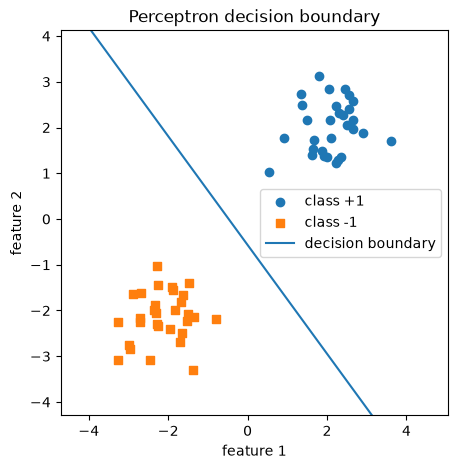

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='o', label='class +1')
ax.scatter(X[y == -1, 0], X[y == -1, 1], marker='s', label='class -1')

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_line = np.linspace(x1_min, x1_max, 100)
# Solve w1*x1 + w2*x2 + b = 0 for x2.
x2_line = -(model.w_[0] * x1_line + model.b_) / model.w_[1]
ax.plot(x1_line, x2_line, label='decision boundary')

ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Perceptron decision boundary')
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.legend()
plt.show()

## Interpretation

The boundary cleanly separates the two blobs, and the training accuracy printed
above reflects that. The mistake count drops over the epochs and reaches zero,
which is the signal that the perceptron has found a separating line and the
early-stopping check ends training.

The weight vector $\mathbf{w}$ is perpendicular to the boundary: it points from
the $-1$ region toward the $+1$ region. The bias $b$ shifts the line away from
the origin.

## When does it converge, and when does it fail?

The **perceptron convergence theorem** guarantees that if the data is linearly
separable, the algorithm makes only a finite number of mistakes and therefore
stops after finitely many updates. That is exactly what we saw here.

If the data is **not** linearly separable (for example, two classes that
overlap, or a pattern like XOR), no straight line can classify every point
correctly. There will always be at least one misclassified example, so the
mistake count never reaches zero and the weights keep changing from epoch to
epoch without settling.

### Limitations and next steps

- The perceptron only learns **linear** boundaries; curved separations are out
  of reach.
- On non-separable data it does not converge and has no built-in notion of the
  *best* line, only *a* separating line.
- It returns hard $\pm 1$ labels rather than calibrated probabilities.

Natural next steps are **logistic regression** (a smooth, probabilistic linear
classifier trained with gradient descent) and the **multilayer perceptron**,
which stacks units to model non-linear boundaries.